# Caso 7 — Variação dos Parâmetros do BM25

Avaliamos as 9 combinações de `k1 ∈ {0,5; 1,2; 2,0}` e `b ∈ {0; 0,75; 1}`,
usando MAP e NDCG@10 (métrica graduada adicional) como critérios de
comparação — todas as demais condições (pré-processamento, coleção,
consultas, qrels) permanecem fixas.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.bm25 import BM25
from src.metrics import evaluate_model

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
doc_len = dict(zip(doc_ids, [len(t) for t in doc_tokens]))


[WARNING] Download failed: 403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz


[cranfield_data] ir_datasets indisponível (RuntimeError: ('All download sources failed', [(RequestsDownload('http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz', tries=None), HTTPError('403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz')), (RequestsDownload('https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5', tries=None), HTTPError('403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5'))])). Usando arquivos locais em data/raw/ como fallback.


[WARNING] Download failed: 403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5


## Grade de parâmetros

In [2]:
# Grade de parâmetros exigida: k1 em {0.5, 1.2, 2.0}, b em {0, 0.75, 1}
# (9 combinações). O índice invertido é construído uma única vez; apenas
# k1/b mudam entre as iterações (set_params não reconstrói o índice).
K1_VALUES = [0.5, 1.2, 2.0]
B_VALUES = [0, 0.75, 1]
K = 10

bm25 = BM25(doc_tokens)
grid_rows = []
rankings_by_param = {}

for k1 in K1_VALUES:
    for b in B_VALUES:
        bm25.set_params(k1=k1, b=b)
        rankings = {qid: [doc_ids[i] for i, _ in bm25.rank(qtoks)]
                    for qid, qtoks in zip(query_ids, query_tokens_list)}
        rankings_by_param[(k1, b)] = rankings
        ev = evaluate_model(rankings, df_qrels, k=K)
        grid_rows.append({
            "k1": k1, "b": b,
            "MAP": ev["AP"].mean(),
            "P@10": ev["precision@10"].mean(),
            "NDCG@10": ev["NDCG@10"].mean(),
        })

df_grid = pd.DataFrame(grid_rows)
display(df_grid.round(4))


,k1,b,MAP,P@10,NDCG@10
0,0.5,0.00,0.2681,0.2004,0.2700
1,0.5,0.75,0.2879,0.2200,0.2880
2,0.5,1.00,0.2908,0.2200,0.2869
3,1.2,0.00,0.2750,0.2080,0.2777
4,1.2,0.75,0.3081,0.2347,0.3065
5,1.2,1.00,0.3051,0.2369,0.3045
6,2.0,0.00,0.2806,0.2107,0.2853
7,2.0,0.75,0.3141,0.2427,0.3113
8,2.0,1.00,0.3094,0.2378,0.3066


## Visualização

Os dois mapas de calor abaixo mostram o mesmo padrão qualitativo em MAP e
NDCG@10.


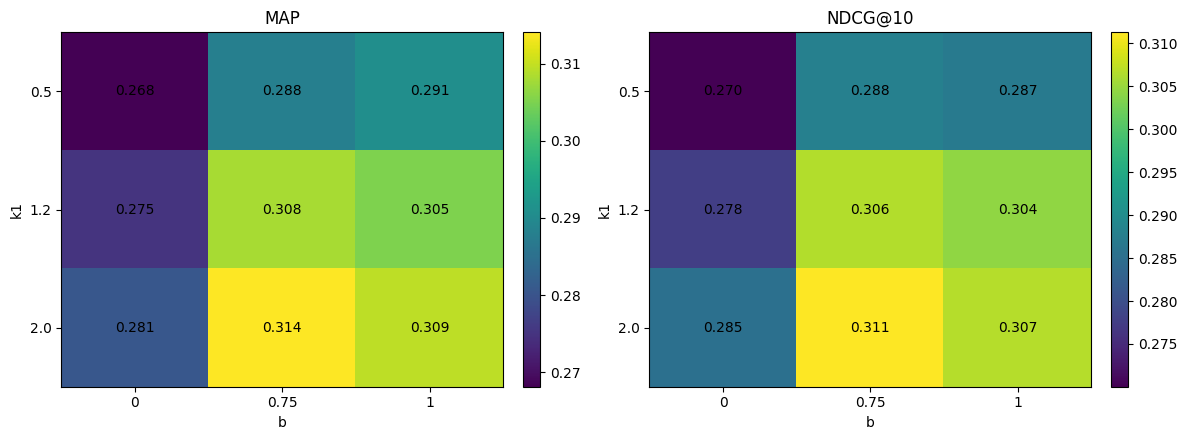

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ["MAP", "NDCG@10"]):
    pivot = df_grid.pivot(index="k1", columns="b", values=metric)
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(B_VALUES))); ax.set_xticklabels(B_VALUES)
    ax.set_yticks(range(len(K1_VALUES))); ax.set_yticklabels(K1_VALUES)
    ax.set_xlabel("b"); ax.set_ylabel("k1"); ax.set_title(metric)
    for i in range(len(K1_VALUES)):
        for j in range(len(B_VALUES)):
            ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center",
                    color="white" if pivot.values[i,j] < pivot.values.max()*0.75 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Efeito de k1 e de b

**Efeito de `b`**: para os três valores de k1 testados, `b=0` (sem
normalização pelo comprimento do documento) é **sempre a pior
configuração** — MAP cai para 0,268–0,281, contra 0,288–0,314 com
`b=0,75` ou `b=1`. Isso confirma que, na coleção Cranfield, documentos
mais longos tendem a acumular termos e frequências por puro tamanho, e
não corrigir esse efeito prejudica o ranking. A diferença entre `b=0,75`
e `b=1` é pequena e não-monotônica (com k1=1,2 e k1=2,0, `b=0,75` é
ligeiramente melhor que `b=1`; com k1=0,5 ocorre o oposto) — sugerindo
que, uma vez que a normalização por comprimento está "ligada" em alguma
magnitude razoável, o ganho marginal de intensificá-la ainda mais é
pequeno e nem sempre positivo para esta coleção (como o estudo de caso
abaixo mostra, `b=1` pode até favorecer documentos *curtos demais*).

**Efeito de `k1`**: dentro da grade testada, aumentar k1 de 0,5 para 2,0
**sempre** melhora o MAP (para qualquer b fixo), embora com retornos
decrescentes (por exemplo, com b=0,75: 0,288 -> 0,308 -> 0,314). Isso
indica que, para os documentos curtos e o vocabulário específico da
Cranfield, permitir que termos repetidos contribuam por mais tempo antes
de saturar (k1 maior) ajuda mais do que prejudica — o que também é
consistente com o padrão observado no Caso 5 (onde a saturação forte,
k1 baixo, ocasionalmente penaliza documentos relevantes que legitimamente
repetem um termo central).

**Melhor combinação testada**: `k1=2,0, b=0,75` (MAP=0,314), acima da
configuração "padrão" usada nos casos anteriores (`k1=1,2, b=0,75`,
MAP=0,308).


## Uma consulta onde `b` muda o ranking perceptivelmente

Para encontrar um exemplo concreto, comparamos o Top-10 obtido com
`k1=1,2` fixo e `b=0` contra `b=1`, em todas as 225 consultas, escolhendo
a de menor sobreposição entre os dois Top-10: a consulta 218 ("qual é a
transferência de calor para um corpo rombudo na ausência de
vorticidade"), que tem 16 documentos julgados (6 deles relevantes,
grau >= 1) — uma consulta rica o suficiente para ver o efeito com clareza.

- **`b=0`**: o topo é dominado por documentos **longos** — o 1º colocado
  (doc 329, não julgado) tem 376 tokens, um dos documentos mais extensos
  da coleção. Ainda assim, 4 documentos relevantes aparecem no Top-10
  (101, 1204, 1393, 1213).
- **`b=0,75`**: os documentos longos perdem posição e o documento 559
  (relevante, grau 3, apenas 55 tokens) assume o 1º lugar; o Top-10 passa
  a ter 3 relevantes bem posicionados (559, 1393, 1213).
- **`b=1`**: a normalização por comprimento fica tão forte que documentos
  **extremamente curtos** (doc 670 com 24 tokens, doc 323 com 43 tokens —
  ambos não julgados) sobem ao Top-10, deslocando o documento relevante
  1213 para fora dele; sobram apenas 2 relevantes no Top-10 (559, 1393).

Este exemplo mostra os dois lados do parâmetro `b`: sem normalização
nenhuma, documentos longos são favorecidos só por acumularem mais termos;
com normalização extrema (`b=1`), documentos muito curtos passam a ser
favorecidos de forma igualmente artificial. Um valor intermediário
(`b=0,75`) equilibra esses dois efeitos — o que explica por que ele
tende a ser competitivo (e, para outras combinações de k1 na grade acima,
até superior a `b=1`) apesar de `b=1` representar a normalização "mais
completa" teoricamente.


In [4]:
# Consulta sensível a b: comparamos, entre todas as 225 consultas, o
# overlap do Top-10 obtido com b=0 vs. b=1 (k1=1.2 fixo), e escolhemos a
# consulta com MENOR overlap — ou seja, onde variar b muda mais o ranking.
k1_fixo = 1.2
r_b0 = rankings_by_param[(k1_fixo, 0)]
r_b1 = rankings_by_param[(k1_fixo, 1)]

overlaps = [(qid, len(set(r_b0[qid][:K]) & set(r_b1[qid][:K]))) for qid in query_ids]
overlaps.sort(key=lambda x: x[1])
qid_sensivel = overlaps[0][0]
print(f"Consulta escolhida: {qid_sensivel} (overlap de Top-10 entre b=0 e b=1: "
      f"{overlaps[0][1]}/10)")
print(f"Texto: {df_queries.set_index('query_id').loc[qid_sensivel, 'text']}")
print(f"Tokens: {query_tokens_list[query_ids.index(qid_sensivel)]}")

grades = dict(zip(df_qrels[df_qrels.query_id == qid_sensivel].doc_id,
                   df_qrels[df_qrels.query_id == qid_sensivel].relevance))

for b in B_VALUES:
    ranking = rankings_by_param[(k1_fixo, b)][qid_sensivel][:10]
    n_rel = sum(1 for d in ranking if grades.get(d, -1) >= 1)
    print(f"\n-- Top-10 com k1={k1_fixo}, b={b} (relevantes no Top-10: {n_rel}) --")
    for rank, did in enumerate(ranking, start=1):
        grade = grades.get(did, "não julgado")
        print(f"  {rank:2d}. doc {did} (len={doc_len[did]:3d} tokens, grau={grade}) "
              f"{doc_title[did][:55]}")


Consulta escolhida: 218 (overlap de Top-10 entre b=0 e b=1: 2/10)
Texto: what is the heat transfer to a blunt body in the absence of vorticity .
Tokens: ['heat', 'transfer', 'blunt', 'bodi', 'absenc', 'vortic']

-- Top-10 com k1=1.2, b=0 (relevantes no Top-10: 4) --
   1. doc 329 (len=376 tokens, grau=não julgado) various aerodynamic characteristics in hypersonic raref
   2. doc 101 (len=192 tokens, grau=1) laminar heat transfer over blunt-nosed bodies at hypers
   3. doc 44 (len=162 tokens, grau=não julgado) tip-bluntness effects on cone pressures at m=6.85 .
   4. doc 1281 (len=130 tokens, grau=não julgado) turbulent heat transfer on blunt-nosed bodies in two-di
   5. doc 1204 (len=183 tokens, grau=3) experimental effect of bluntness and gas rarefaction on
   6. doc 1147 (len=239 tokens, grau=não julgado) heat transfer to bodies traveling at high speed in the 
   7. doc 1393 (len=114 tokens, grau=1) heat transfer near the forward stagnation point of a bo
   8. doc 572 (len=243 tokens